In [1]:
# Cell paling atas Fase 2 (sama seperti di Fase 1)
import time
waktu = {}
def mulai():
    global _t; _t = time.perf_counter()
def selesai(nama):
    waktu[nama] = time.perf_counter() - _t
    print(f"⏱️ {nama}: {waktu[nama]:.2f} detik")
def ringkasan(judul, tahap_analisis=None):
    print(f"\n=== RINGKASAN WAKTU — {judul} ===")
    for n, d in waktu.items(): print(f"{n:30s}: {d:8.2f} detik")
    if tahap_analisis:
        print(f"\n>> Total waktu analisis: {sum(waktu.get(t,0) for t in tahap_analisis):.2f} detik")

In [2]:
# TAHAP 2.1: Pemodelan Dependensi Modul (Pemisahan Intra & Inter)
mulai()
import pandas as pd
from google.colab import drive

print("Memuat dataset dari Fase 1...")
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/Riset_Moodle'
df_raw = pd.read_csv(f'{DRIVE_PATH}/moodle_dependencies_full.csv')

# Fungsi Ekstraksi Modul Detail (Dilengkapi Path Sanitizer)
def ekstrak_identitas_modul(path_file):
    if pd.isna(path_file) or str(path_file).strip() in ['', 'Unknown', 'Fungsi: ()']: return 'Unknown'
    if str(path_file).startswith('Fungsi:'): return 'Function_Call_Logic'

    path_str = str(path_file)

    # === THE FIX: PATH SANITIZER ===
    # Jika path diawali dengan 'public/', potong bagian tersebut agar selaras dengan file tujuan
    if path_str.startswith('public/'):
        path_str = path_str.replace('public/', '', 1)
    # ===============================

    parts = path_str.split('/')
    folder = parts[0]
    core_krusial = {'admin', 'lib', 'course', 'backup', 'auth'}

    if folder == 'mod' and len(parts) >= 2: return f"mod_{parts[1]}"
    elif folder in core_krusial: return f"core_{folder}"
    else: return "Other_Core"

print("Menerjemahkan relasi file menjadi relasi modul...")
df_raw['Modul_Sumber'] = df_raw['File_Sumber'].apply(ekstrak_identitas_modul)
df_raw['Modul_Tujuan'] = df_raw['File_Tujuan'].apply(ekstrak_identitas_modul)

# Membersihkan data yang gagal diidentifikasi
df_clean = df_raw[(df_raw['Modul_Sumber'] != 'Unknown') & (df_raw['Modul_Tujuan'] != 'Unknown')]
df_clean = df_clean[df_clean['Modul_Tujuan'] != 'Function_Call_Logic']

# PEMISAHAN LOGIKA ARSITEKTUR
df_intra = df_clean[df_clean['Modul_Sumber'] == df_clean['Modul_Tujuan']]
df_inter = df_clean[df_clean['Modul_Sumber'] != df_clean['Modul_Tujuan']]

print(f"Pemodelan selesai! Ditemukan {len(df_intra)} relasi internal dan {len(df_inter)} relasi eksternal.")
selesai("Fase2 - Pemodelan")

Memuat dataset dari Fase 1...
Mounted at /content/drive
Menerjemahkan relasi file menjadi relasi modul...
Pemodelan selesai! Ditemukan 7503 relasi internal dan 11879 relasi eksternal.
⏱️ Fase2 - Pemodelan: 29.13 detik


In [4]:
# TAHAP 2.2: Pengukuran Cohesion dan Coupling (Rumus Metrik)
mulai()
import pandas as pd
from google.colab import data_table   # <-- PINDAHKAN KE SINI (sebelum dipakai)

# 1. Hitung Variabel Dasar
intra_links = df_intra.groupby('Modul_Sumber').size().rename('Koneksi_Internal')   # E_intra
fan_out     = df_inter.groupby('Modul_Sumber').size().rename('Fan_Out')            # Ce
fan_in      = df_inter.groupby('Modul_Tujuan').size().rename('Fan_In')             # Ca

# 2. Gabungkan ke satu DataFrame Master
modul_unik = pd.Series(
    pd.concat([df_clean['Modul_Sumber'], df_clean['Modul_Tujuan']]).unique(),
    name='Nama_Modul'
)
df_metrics = pd.DataFrame(modul_unik).set_index('Nama_Modul')
df_metrics = df_metrics.join([intra_links, fan_out, fan_in]).fillna(0)

# 3. Penerapan Rumus
df_metrics['Cohesion_Ratio']   = df_metrics['Koneksi_Internal'] / (df_metrics['Koneksi_Internal'] + df_metrics['Fan_Out'])
df_metrics['Instability_Index'] = df_metrics['Fan_Out'] / (df_metrics['Fan_In'] + df_metrics['Fan_Out'])
df_metrics = df_metrics.fillna(0).round(3)   # tangani pembagian nol (NaN)

# 4. Pisahkan Plugin (mod_*) dan Core (selain mod_*)
df_plugin_rapor = df_metrics[df_metrics.index.str.startswith('mod_')].sort_values('Instability_Index', ascending=False)
df_core_rapor   = df_metrics[~df_metrics.index.str.startswith('mod_')].sort_values('Fan_In', ascending=False)

# 5. Tampilkan + Ekspor
print("\n=== RAPOR MODULARITAS CORE MOODLE (MESIN INTI) ===")
display(data_table.DataTable(df_core_rapor.reset_index(), include_index=False, num_rows_per_page=10))

print("\n=== RAPOR MODULARITAS PLUGIN MOODLE ===")
display(data_table.DataTable(df_plugin_rapor.reset_index(), include_index=False, num_rows_per_page=15))

df_metrics.to_csv(f'{DRIVE_PATH}/rapor_metrik_modularitas_master.csv')
print(f"\n[SUKSES] Data master (Core + Plugin) diekspor ke: {DRIVE_PATH}/rapor_metrik_modularitas_master.csv")

selesai("Fase2 - Metrik")


=== RAPOR MODULARITAS CORE MOODLE (MESIN INTI) ===


,Nama_Modul,Koneksi_Internal,Fan_Out,Fan_In,Cohesion_Ratio,Instability_Index
0,Other_Core,5699,656,10455.0,0.897,0.059
1,core_lib,334,4967,1115.0,0.063,0.817
2,core_course,110,629,156.0,0.149,0.801
3,core_backup,390,344,118.0,0.531,0.745
4,core_auth,17,127,4.0,0.118,0.969
5,core_admin,11,2191,1.0,0.005,1.000



=== RAPOR MODULARITAS PLUGIN MOODLE ===


,Nama_Modul,Koneksi_Internal,Fan_Out,Fan_In,Cohesion_Ratio,Instability_Index
0,mod_choice,10,46,0.0,0.179,1.000
1,mod_resource,13,30,0.0,0.302,1.000
2,mod_workshop,36,240,0.0,0.130,1.000
3,mod_imscp,11,26,0.0,0.297,1.000
4,mod_book,11,88,0.0,0.111,1.000
5,mod_folder,9,27,0.0,0.250,1.000
6,mod_scorm,75,172,0.0,0.304,1.000
7,mod_page,9,23,0.0,0.281,1.000
8,mod_subsection,2,18,0.0,0.100,1.000
9,mod_bigbluebuttonbn,5,100,0.0,0.048,1.000



[SUKSES] Data master (Core + Plugin) diekspor ke: /content/drive/MyDrive/Riset_Moodle/rapor_metrik_modularitas_master.csv
⏱️ Fase2 - Metrik: 0.37 detik


Visualisasi graf telah disimpan di: /content/drive/MyDrive/Riset_Moodle/visualisasi_modularitas.png


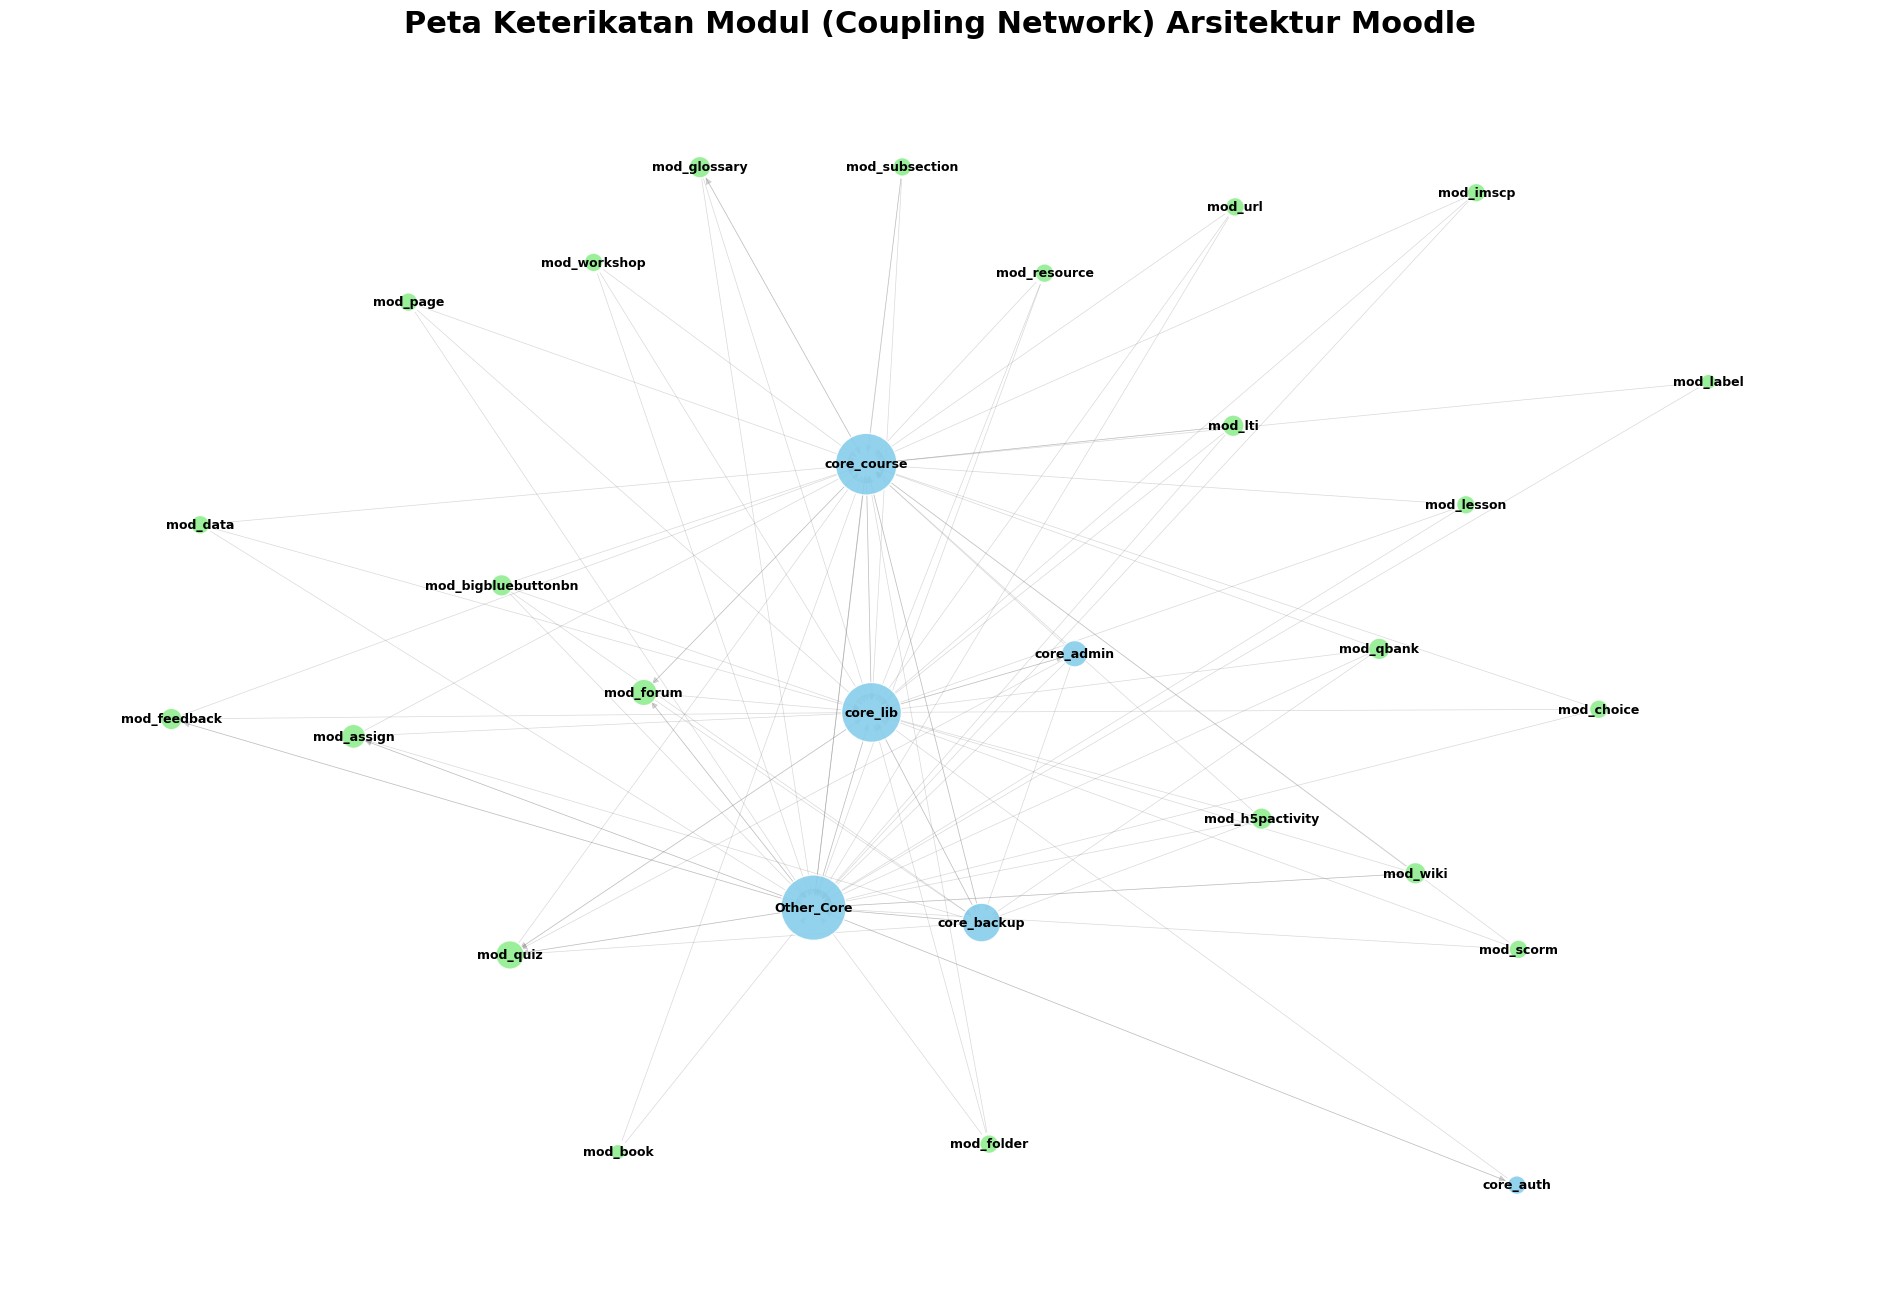

⏱️ Fase2 - Visualisasi: 4.51 detik

=== RINGKASAN WAKTU — FASE 2 ===
Fase2 - Pemodelan             :    29.13 detik
Fase2 - Metrik                :     0.37 detik
Fase2 - Visualisasi           :     4.51 detik

>> Total waktu analisis: 29.50 detik


In [5]:
# TAHAP 2.3: Visualisasi Jaringan Modularitas (Coupling Network)
mulai()
import networkx as nx
import matplotlib.pyplot as plt

# Agregasi bobot (ketebalan garis) antar modul
df_adj = df_inter.groupby(['Modul_Sumber', 'Modul_Tujuan']).size().reset_index(name='Weight')

# Inisialisasi Kanvas Lebar
plt.figure(figsize=(24, 16))
G = nx.from_pandas_edgelist(df_adj, 'Modul_Sumber', 'Modul_Tujuan', ['Weight'], create_using=nx.DiGraph())

# Layout Algoritma (Spring layout memisahkan node yang jarang berinteraksi)
pos = nx.spring_layout(G, k=0.4, iterations=70)

# Ukuran node ditentukan oleh Fan-In (Seberapa banyak ia dipanggil)
node_sizes = [v * 60 for v in dict(G.degree()).values()]

# Warna Node: Core berwarna Biru, Plugin berwarna Hijau
node_colors = ['skyblue' if str(node).startswith('core_') or node == 'Other_Core' else 'lightgreen' for node in G.nodes()]

# Menggambar elemen graf
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, edge_color='gray', arrowsize=10)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_family='sans-serif')

plt.title("Peta Keterikatan Modul (Coupling Network) Arsitektur Moodle", fontsize=22, fontweight='bold', pad=20)
plt.axis('off')

# Simpan gambar High-Res ke Drive
IMG_PATH = f'{DRIVE_PATH}/visualisasi_modularitas.png'
plt.savefig(IMG_PATH, dpi=300, bbox_inches='tight')
print(f"Visualisasi graf telah disimpan di: {IMG_PATH}")
plt.show()
selesai("Fase2 - Visualisasi")
ringkasan("FASE 2", tahap_analisis=["Fase2 - Pemodelan", "Fase2 - Metrik"])

Membuat visualisasi graph versi paper...
Jumlah relasi unik antar modul: 103
Jumlah node/modul: 29
Jumlah edge/dependency: 103


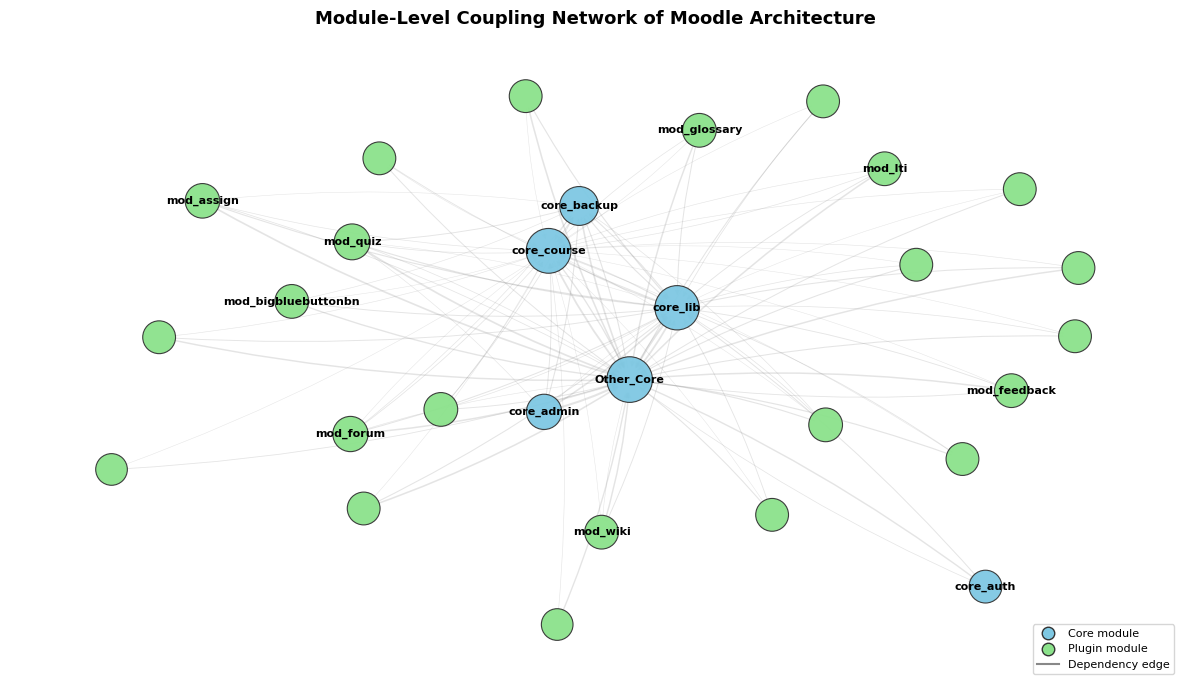

Visualisasi selesai.
File PNG disimpan di: /content/drive/MyDrive/Riset_Moodle/figure1_moodle_coupling_network_paper.png
File PDF disimpan di: /content/drive/MyDrive/Riset_Moodle/figure1_moodle_coupling_network_paper.pdf


In [ ]:
# ============================================================
# VISUALISASI GRAPH VERSI PAPER
# Simplified Coupling Network Moodle
# ============================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

print("Membuat visualisasi graph versi paper...")

# ------------------------------------------------------------
# 1. Membuat data relasi antar modul dari df_inter
# ------------------------------------------------------------
# df_inter = relasi eksternal antar modul
# Contoh: mod_quiz -> core_lib
# Relasi yang sama digabung dan dihitung sebagai Weight

df_adj = (
    df_inter
    .groupby(["Modul_Sumber", "Modul_Tujuan"])
    .size()
    .reset_index(name="Weight")
)

print(f"Jumlah relasi unik antar modul: {len(df_adj)}")


# ------------------------------------------------------------
# 2. Membuat directed graph
# ------------------------------------------------------------
# Directed graph dipakai karena arah dependency penting.
# Contoh: mod_quiz -> core_lib berarti mod_quiz bergantung pada core_lib.

G = nx.from_pandas_edgelist(
    df_adj,
    source="Modul_Sumber",
    target="Modul_Tujuan",
    edge_attr="Weight",
    create_using=nx.DiGraph()
)

print(f"Jumlah node/modul: {G.number_of_nodes()}")
print(f"Jumlah edge/dependency: {G.number_of_edges()}")


# ------------------------------------------------------------
# 3. Mengatur posisi node
# ------------------------------------------------------------
# spring_layout digunakan agar node yang saling terhubung berada lebih dekat.
# seed digunakan supaya posisi graph konsisten setiap kali dijalankan.

pos = nx.spring_layout(
    G,
    k=1.25,          # semakin besar, jarak antar node semakin longgar
    iterations=500,  # semakin besar, layout semakin stabil
    seed=42,
    weight=None
)


# ------------------------------------------------------------
# 4. Menentukan jenis node: core atau plugin
# ------------------------------------------------------------

core_nodes = [
    node for node in G.nodes()
    if str(node).startswith("core_") or node == "Other_Core"
]

plugin_nodes = [
    node for node in G.nodes()
    if str(node).startswith("mod_")
]


# ------------------------------------------------------------
# 5. Mengatur ukuran node
# ------------------------------------------------------------
# Ukuran node memakai total degree.
# Total degree = relasi masuk + relasi keluar.
# Jadi, node besar berarti modul tersebut banyak terhubung.

degree_dict = dict(G.degree())

node_sizes = [
    350 + 120 * np.sqrt(degree_dict.get(node, 1))
    for node in G.nodes()
]


# ------------------------------------------------------------
# 6. Mengatur warna node
# ------------------------------------------------------------
# Biru  = modul core
# Hijau = modul plugin

node_colors = [
    "#7EC8E3" if node in core_nodes else "#8BE28B"
    for node in G.nodes()
]


# ------------------------------------------------------------
# 7. Mengatur ketebalan edge berdasarkan Weight
# ------------------------------------------------------------
# Weight besar tidak dibuat terlalu tebal secara ekstrem.
# Maka dipakai log agar tetap rapi.

weights = np.array([G[u][v]["Weight"] for u, v in G.edges()])
max_weight = weights.max() if len(weights) > 0 else 1

edge_widths = [
    0.25 + 1.4 * (np.log1p(G[u][v]["Weight"]) / np.log1p(max_weight))
    for u, v in G.edges()
]


# ------------------------------------------------------------
# 8. Menentukan node yang diberi label
# ------------------------------------------------------------
# Untuk paper, jangan labeli semua node.
# Label hanya diberikan pada:
# - semua core
# - beberapa plugin paling terhubung

top_plugin_count = 8

top_plugin_nodes = sorted(
    plugin_nodes,
    key=lambda node: degree_dict.get(node, 0),
    reverse=True
)[:top_plugin_count]

label_nodes = set(core_nodes + top_plugin_nodes)

labels = {
    node: node
    for node in label_nodes
}


# ------------------------------------------------------------
# 9. Menggambar graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Edge / garis dependency
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=8,
    width=edge_widths,
    edge_color="#888888",
    alpha=0.22,
    connectionstyle="arc3,rad=0.06"
)

# Node / modul
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="#333333",
    linewidths=0.8,
    alpha=0.95
)

# Label hanya untuk node penting
nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8,
    font_weight="bold",
    font_family="sans-serif"
)


# ------------------------------------------------------------
# 10. Legend
# ------------------------------------------------------------

legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Core module",
        markerfacecolor="#7EC8E3",
        markeredgecolor="#333333",
        markersize=9
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Plugin module",
        markerfacecolor="#8BE28B",
        markeredgecolor="#333333",
        markersize=9
    ),
    Line2D(
        [0], [0],
        color="#888888",
        lw=1.5,
        label="Dependency edge"
    )
]

plt.legend(
    handles=legend_items,
    loc="lower right",
    frameon=True,
    fontsize=8
)


# ------------------------------------------------------------
# 11. Finalisasi tampilan
# ------------------------------------------------------------
# Judul sengaja tidak dibuat terlalu besar.
# Kalau mau benar-benar untuk paper, judul bisa dihapus dan diganti caption di bawah gambar.

plt.title(
    "Module-Level Coupling Network of Moodle Architecture",
    fontsize=13,
    fontweight="bold",
    pad=12
)

plt.axis("off")
plt.tight_layout()


# ------------------------------------------------------------
# 12. Simpan gambar ke Google Drive
# ------------------------------------------------------------

OUTPUT_PNG = f"{DRIVE_PATH}/figure1_moodle_coupling_network_paper.png"
OUTPUT_PDF = f"{DRIVE_PATH}/figure1_moodle_coupling_network_paper.pdf"

plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUTPUT_PDF, bbox_inches="tight")

plt.show()

print("Visualisasi selesai.")
print(f"File PNG disimpan di: {OUTPUT_PNG}")
print(f"File PDF disimpan di: {OUTPUT_PDF}")